In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("store_customers.csv")

print(df.head())
print(df.shape)

   CustomerID Gender   Age  Annual Income (k$)  Spending Score (1-100)
0        1000      M  39.0                59.9                    58.0
1        1001      M  34.0                48.4                    37.0
2        1002      F  40.0                70.5                    26.0
3        1003      F  47.0                81.1                    30.0
4        1004      F  33.0                42.1                    58.0
(1000, 5)


In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB
None
        CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  1000.000000  994.000000          996.000000              994.000000
mean   1499.500000   38.935614           57.149096               42.645875
std     288.819436   13.399880           28.628506               20.101589
min    1000.000000   18.000000           15.000000                1.000000
25%    1249.750000   30.000000           34.975000               31.000000
50%   

In [ ]:
# Data Cleaning

print(df.isnull().sum())

df = df.dropna()

df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64


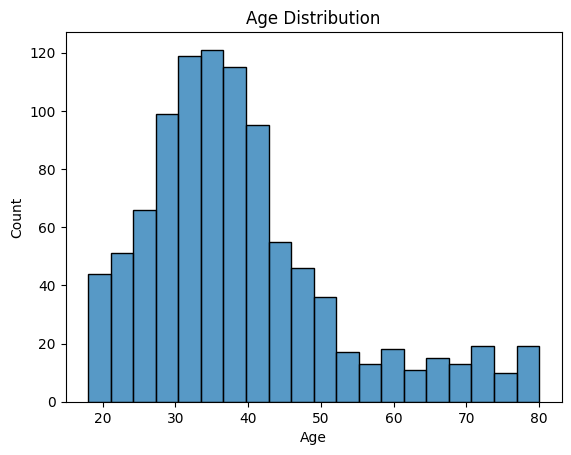

In [ ]:
sns.histplot(df['Age'], bins=20)
plt.title("Age Distribution")
plt.show()

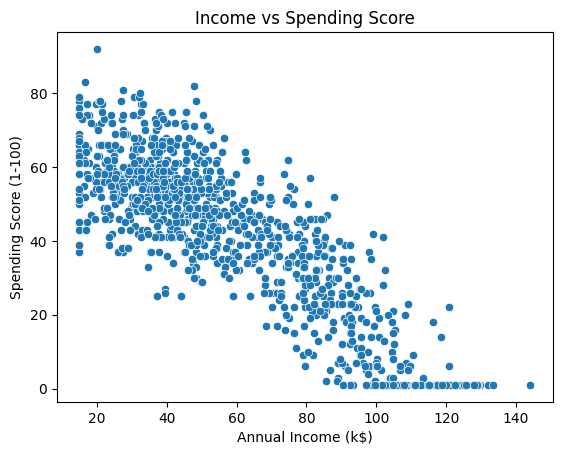

In [ ]:
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df)
plt.title("Income vs Spending Score")
plt.show()

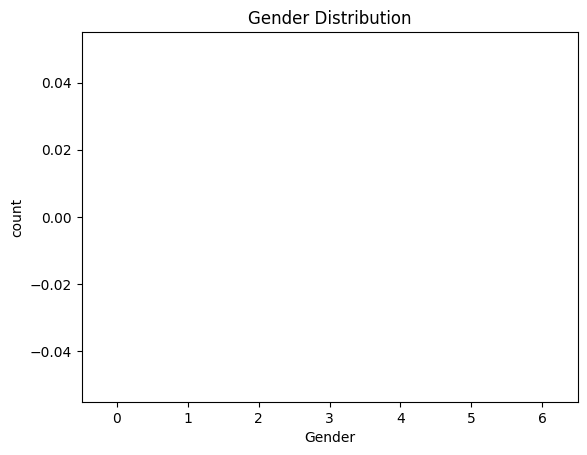

In [ ]:
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

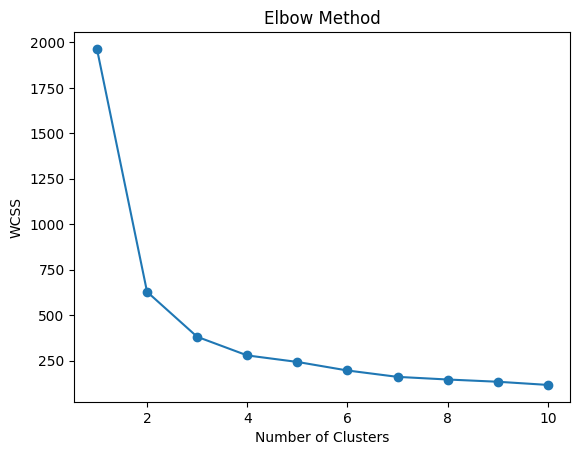

In [ ]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

df['Cluster'] = y_kmeans

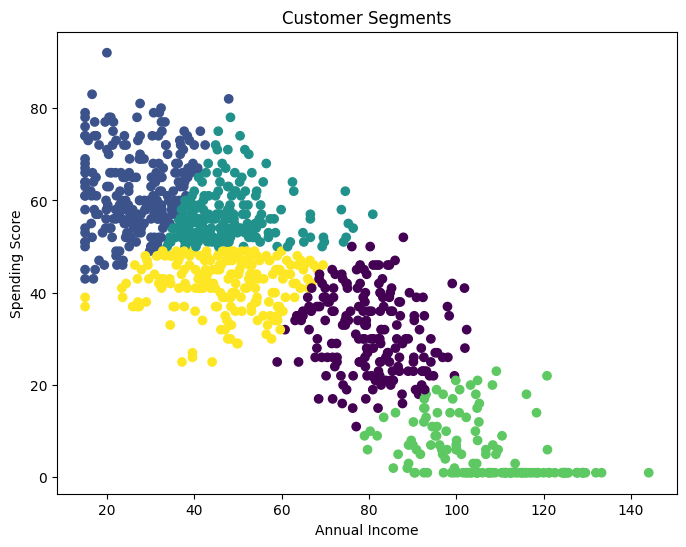

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
            c=df['Cluster'], cmap='viridis')

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")

plt.show()

In [ ]:
print(df.groupby('Cluster').mean())

          CustomerID  Gender        Age  Annual Income (k$)  \
Cluster                                                       
0        1471.690722     NaN  44.855670           80.541753   
1        1458.995868     NaN  26.855372           26.916529   
2        1423.459184     NaN  34.520408           47.584184   
3        1811.394366     NaN  64.584507          106.266197   
4        1435.086538     NaN  34.225962           46.825481   

         Spending Score (1-100)  
Cluster                          
0                     31.587629  
1                     62.012397  
2                     56.668367  
3                      5.753521  
4                     42.201923  


In [15]:
!git clone https://github.com/aayushpatil25/Customer-Segmentation-using-clustering-.git


Cloning into 'Customer-Segmentation-using-clustering-'...


In [17]:
!cp /content/*.ipynb /content/CustomerSegmentation/

cp: cannot stat '/content/*.ipynb': No such file or directory
